In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [3]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv("D:\\carbon\\carbon_emission_dataset_with_Industry.csv")

In [6]:
df.head()

,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,...,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,...,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,...,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,...,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,...,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,...,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing


In [7]:
print("Shape:", df.shape)

Shape: (18250, 22)


In [8]:
print(df.columns)

Index(['Company_ID', 'Date', 'Sector', 'Total_Energy_Consumption_kWh',
       'Renewable_Energy_Consumption_kWh',
       'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units',
       'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode',
       'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET',
       'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent',
       'Employment_Count', 'Public_Acceptance_Index',
       'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD',
       'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent',
       'Social_Impact_Score', 'Industry_Sectors'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Company_ID                           18250 non-null  object 
 1   Date                                 18250 non-null  object 
 2   Sector                               18250 non-null  object 
 3   Total_Energy_Consumption_kWh         18250 non-null  float64
 4   Renewable_Energy_Consumption_kWh     18250 non-null  float64
 5   NonRenewable_Energy_Consumption_kWh  18250 non-null  float64
 6   Production_Output_Units              18250 non-null  float64
 7   Supply_Chain_Transport_km            18250 non-null  float64
 8   Supply_Chain_Transport_Mode          18250 non-null  object 
 9   Raw_Material_Usage_kg                18250 non-null  float64
 10  Carbon_Emission_tCO2e_TARGET         18250 non-null  float64
 11  Energy_Cost_USD             

In [10]:
df.describe(include="all")

,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,...,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
count,18250,18250,18250,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250,18250.000000,...,18250.000000,18250.000000,18250.000000,18250.000000,18250,18250.000000,18250.000000,18250.000000,18250.000000,18250
unique,50,365,5,NaN,NaN,NaN,NaN,NaN,4,NaN,...,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,4
top,C001,2024-01-01,Manufacturing,NaN,NaN,NaN,NaN,NaN,Ship,NaN,...,NaN,NaN,NaN,NaN,Process Reengineering,NaN,NaN,NaN,NaN,Steel Manufacturing
freq,365,50,5110,NaN,NaN,NaN,NaN,NaN,4581,NaN,...,NaN,NaN,NaN,NaN,4632,NaN,NaN,NaN,NaN,4563
mean,NaN,NaN,NaN,124776.987158,43759.097184,81017.889975,5538.963915,2734.813587,NaN,44869.415215,...,1129.541275,77.623844,2734.349041,0.624569,NaN,299333.028470,15.067031,47.637350,0.674542,NaN
std,NaN,NaN,NaN,43106.624251,24291.666951,33957.852247,2597.576117,1300.146027,NaN,20110.509566,...,590.407029,10.112534,1298.648265,0.187841,NaN,115674.898008,5.794350,15.086466,0.159451,NaN
min,NaN,NaN,NaN,50008.730000,5041.200000,20483.260000,1000.470000,500.380000,NaN,10006.500000,...,155.740000,60.000000,500.000000,0.300000,NaN,100052.340000,5.000000,15.250000,0.400000,NaN
25%,NaN,NaN,NaN,87326.365000,24455.502500,53738.547500,3273.995000,1609.122500,NaN,27439.335000,...,682.407500,68.880000,1603.000000,0.460000,NaN,199132.372500,10.040000,35.240000,0.540000,NaN
50%,NaN,NaN,NaN,124728.530000,38888.005000,77007.820000,5556.400000,2735.020000,NaN,44803.630000,...,1012.145000,77.660000,2730.000000,0.625000,NaN,297477.130000,15.100000,47.660000,0.680000,NaN
75%,NaN,NaN,NaN,162042.955000,59545.025000,104085.372500,7802.095000,3862.717500,NaN,62291.027500,...,1464.847500,86.317500,3853.750000,0.790000,NaN,399960.932500,20.070000,60.190000,0.810000,NaN


In [11]:
df.isnull().sum()

Company_ID                             0
Date                                   0
Sector                                 0
Total_Energy_Consumption_kWh           0
Renewable_Energy_Consumption_kWh       0
NonRenewable_Energy_Consumption_kWh    0
Production_Output_Units                0
Supply_Chain_Transport_km              0
Supply_Chain_Transport_Mode            0
Raw_Material_Usage_kg                  0
Carbon_Emission_tCO2e_TARGET           0
Energy_Cost_USD                        0
Carbon_Tax_USD                         0
Process_Efficiency_Percent             0
Employment_Count                       0
Public_Acceptance_Index                0
Carbon_Reduction_Strategy              0
Strategy_Implementation_Cost_USD       0
Expected_Carbon_Reduction_Percent      0
Expected_Renewable_Share_Percent       0
Social_Impact_Score                    0
Industry_Sectors                       0
dtype: int64

In [12]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [13]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day

In [14]:
df.head()

,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,...,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors,year,month,day
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,...,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing,2024,1,1
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,...,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production,2024,1,2
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,...,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry,2024,1,3
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,...,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics,2024,1,4
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,...,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing,2024,1,5


In [15]:
target = "Carbon_Emission_tCO2e_TARGET"

In [16]:
X = df.drop(columns=["Date", target])
y = df[target]

In [17]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (18250, 23)
Target shape: (18250,)


In [18]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['Company_ID', 'Sector', 'Supply_Chain_Transport_Mode', 'Carbon_Reduction_Strategy', 'Industry_Sectors']

Numeric columns:
['Total_Energy_Consumption_kWh', 'Renewable_Energy_Consumption_kWh', 'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units', 'Supply_Chain_Transport_km', 'Raw_Material_Usage_kg', 'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent', 'Employment_Count', 'Public_Acceptance_Index', 'Strategy_Implementation_Cost_USD', 'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent', 'Social_Impact_Score', 'year', 'month', 'day']


In [20]:
## SPLITLING DATA INTO TRAINING AND TESTING DATA

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14600, 23)
X_test: (3650, 23)
y_train: (14600,)
y_test: (3650,)


In [21]:
## PREPROCESSING

In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [23]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [25]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

In [26]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [27]:
y_pred = model.predict(X_test)

In [28]:
print(y_pred[:10])

[34.69619863 15.78293275 37.46899816 41.0108575  28.16171661 43.91306776
 53.23941234 51.4198329  17.12321509 16.07939972]


In [30]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.2798197503426594
RMSE: 4.287766808484926
R2 Score: 0.9125923545349848


In [31]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,37.4498,34.696199
1,15.8726,15.782933
2,44.9836,37.468998
3,38.9649,41.010858
4,28.5057,28.161717
5,33.2754,43.913068
6,48.9647,53.239412
7,60.6673,51.419833
8,20.8577,17.123215
9,20.4847,16.079400


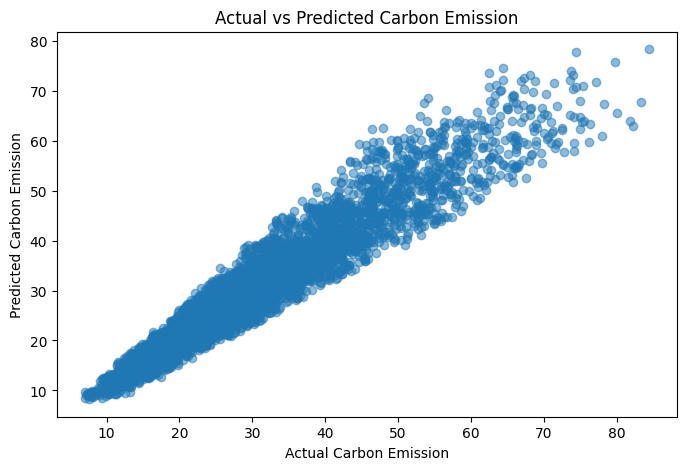

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(results["Actual"], results["Predicted"], alpha=0.5)
plt.xlabel("Actual Carbon Emission")
plt.ylabel("Predicted Carbon Emission")
plt.title("Actual vs Predicted Carbon Emission")
plt.show()

In [33]:
joblib.dump(model, "carbon_emission_model.joblib")
print("Model saved successfully!")

Model saved successfully!


In [34]:
loaded_model = joblib.load("carbon_emission_model.joblib")
print("Model loaded successfully!")

Model loaded successfully!
